# DiffBind: Differential Binding Analysis


In [1]:
library(DiffBind)
    library(DESeq2)
    library(ChIPseeker)
    library(GenomicFeatures)
    library(org.Mm.eg.db)
    library(ggplot2)
    library(dplyr)
    library(readr)
    library(tibble)

# --- change this to run a different factor ---
TF <- 'H3K4me3'   

# --- paths ---
MANIFEST  <- '../0_samplesheets/sample_manifest.tsv'
BAM_DIR   <- '../2_aligned'
PEAK_DIR  <- '../3_peaks'
GTF       <- '../igenomes/Mus_musculus/UCSC/mm10/Annotation/Genes/genes.gtf'
OUT_DIR   <- '0_outputs'

PEAK_TYPE   <- "relaxed"
PEAK_SUFFIX <- paste0(".seacr.peaks.", PEAK_TYPE, ".bed")

# --- settings ---
TSS_UP     <- 3000    # bp upstream of TSS for promoter annotation
TSS_DOWN   <- 3000    # bp downstream of TSS for promoter annotation
FDR_THRESH <- 0.05

dir.create(OUT_DIR, showWarnings=FALSE)
cat('Running TF:', TF, '\n')

Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomeInfoDb

Loa

Running TF: H3K4me3 


In [3]:
manifest <- read_tsv(MANIFEST, show_col_types = FALSE)

build_samplesheet <- function(tf_manifest, bam_dir, peak_dir) {
    # nf-core names samples as {group}_R{replicate}, e.g. GFP_H3K4me3_R1
    nf_id <- paste0(tf_manifest$sample_name, '_R', sub('.*_', '', tf_manifest$sample_id))
    data.frame(
        SampleID   = tf_manifest$sample_id,
        Tissue     = tf_manifest$tf[1],
        Factor     = tf_manifest$tf[1],
        Condition  = tf_manifest$group,
        Replicate  = ave(tf_manifest$sample_id, tf_manifest$group, FUN = seq_along),
        bamReads   = file.path(bam_dir, paste0(nf_id, '.final.bam')),
        Peaks      = file.path(peak_dir, paste0(nf_id, PEAK_SUFFIX)),
        PeakCaller = 'bed',
        stringsAsFactors = FALSE
    )

}

In [4]:
tf_manifest <- manifest %>% filter(tf == TF)
ss <- build_samplesheet(tf_manifest, BAM_DIR, PEAK_DIR)

In [5]:
dba_obj <- dba(sampleSheet=ss)
dba_obj

GFP_H3K4me3_1 H3K4me3 H3K4me3 GFP  1 bed

GFP_H3K4me3_2 H3K4me3 H3K4me3 GFP  2 bed

GFP_H3K4me3_3 H3K4me3 H3K4me3 GFP  3 bed

GFP_H3K4me3_4 H3K4me3 H3K4me3 GFP  4 bed

TFF1_H3K4me3_1 H3K4me3 H3K4me3 TFF1  1 bed

TFF1_H3K4me3_2 H3K4me3 H3K4me3 TFF1  2 bed

TFF1_H3K4me3_3 H3K4me3 H3K4me3 TFF1  3 bed

TFF1_H3K4me3_4 H3K4me3 H3K4me3 TFF1  4 bed



8 Samples, 18910 sites in matrix (33202 total):
              ID  Tissue  Factor Condition Replicate Intervals
1  GFP_H3K4me3_1 H3K4me3 H3K4me3       GFP         1     14351
2  GFP_H3K4me3_2 H3K4me3 H3K4me3       GFP         2     12086
3  GFP_H3K4me3_3 H3K4me3 H3K4me3       GFP         3     16936
4  GFP_H3K4me3_4 H3K4me3 H3K4me3       GFP         4     13337
5 TFF1_H3K4me3_1 H3K4me3 H3K4me3      TFF1         1     31906
6 TFF1_H3K4me3_2 H3K4me3 H3K4me3      TFF1         2     15525
7 TFF1_H3K4me3_3 H3K4me3 H3K4me3      TFF1         3     13892
8 TFF1_H3K4me3_4 H3K4me3 H3K4me3      TFF1         4     20918

In [6]:
# summits=FALSE keeps the SEACR IgG peak coordinates as-is
# Inspect: reads per sample, FRiP (fraction of reads in peaks)
dba_obj <- dba.count(dba_obj, summits=FALSE, bParallel=TRUE)
dba_obj

8 Samples, 12681 sites in matrix:
              ID  Tissue  Factor Condition Replicate    Reads FRiP
1  GFP_H3K4me3_1 H3K4me3 H3K4me3       GFP         1 37446178 0.30
2  GFP_H3K4me3_2 H3K4me3 H3K4me3       GFP         2 28283082 0.27
3  GFP_H3K4me3_3 H3K4me3 H3K4me3       GFP         3 29691146 0.32
4  GFP_H3K4me3_4 H3K4me3 H3K4me3       GFP         4 29170372 0.31
5 TFF1_H3K4me3_1 H3K4me3 H3K4me3      TFF1         1 33704107 0.22
6 TFF1_H3K4me3_2 H3K4me3 H3K4me3      TFF1         2 32605082 0.21
7 TFF1_H3K4me3_3 H3K4me3 H3K4me3      TFF1         3 35342556 0.22
8 TFF1_H3K4me3_4 H3K4me3 H3K4me3      TFF1         4 34369972 0.23

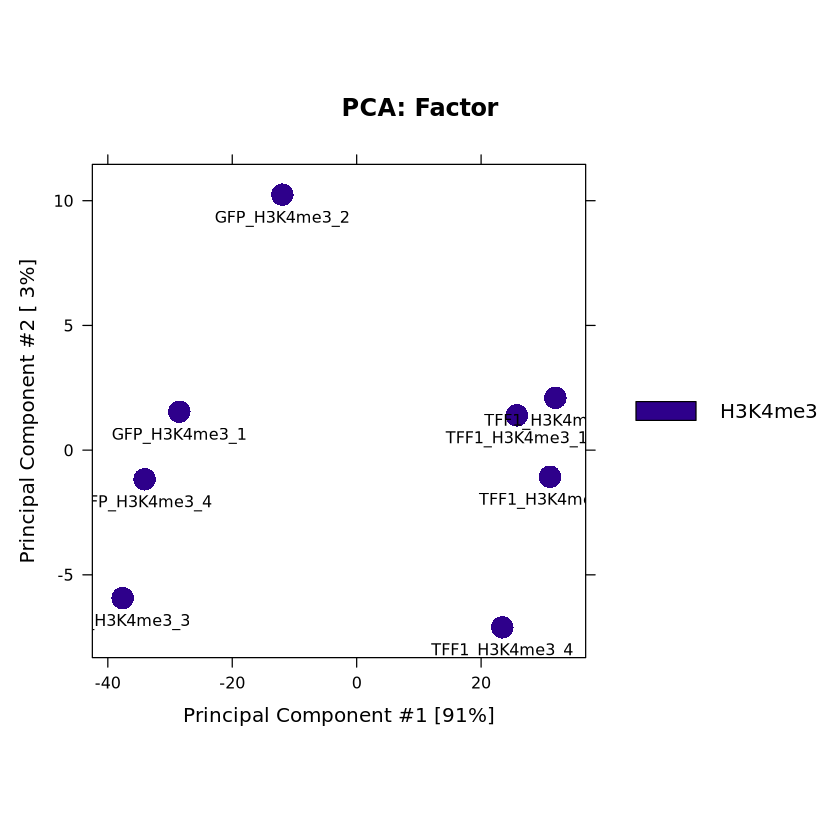

In [7]:
dba.plotPCA(dba_obj,  attributes=DBA_FACTOR, label=DBA_ID)

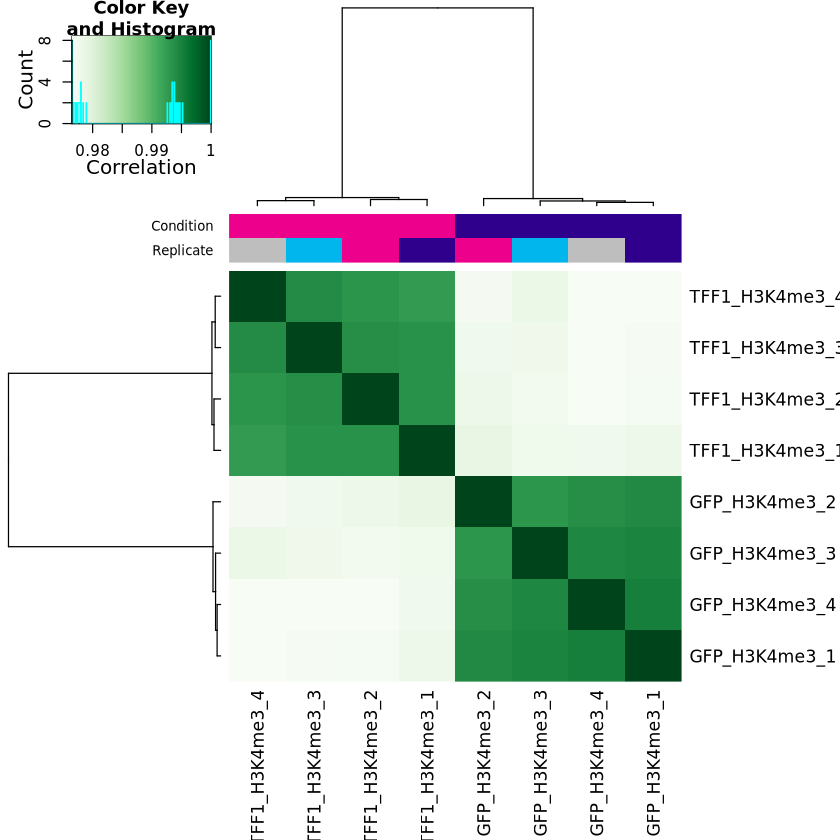

In [8]:
plot(dba_obj)

In [9]:
cts <- dba.peakset(dba_obj, bRetrieve=TRUE, DataType=DBA_DATA_FRAME)
cat('Peaks:', nrow(cts), '\n')
cat('Range of counts across peaks:\n')
print(summary(rowSums(cts[, -(1:3)])))
cat('Samples with zero total counts:\n')
print(colSums(cts[, -(1:3)]))

Peaks: 12681 
Range of counts across peaks:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  475.4  2502.4  4501.9  5368.8  7004.0 70186.2 
Samples with zero total counts:
 GFP_H3K4me3_1  GFP_H3K4me3_2  GFP_H3K4me3_3  GFP_H3K4me3_4 TFF1_H3K4me3_1 
       9849240        8794663       10505269       10253851        7244189 
TFF1_H3K4me3_2 TFF1_H3K4me3_3 TFF1_H3K4me3_4 
       6967800        7033747        7432326 


In [10]:
dba_obj <- dba.normalize(dba_obj)

norm <- dba.normalize(dba_obj, bRetrieve=TRUE)
norm

$norm.method
[1] "lib"

$norm.factors
[1] 1.1494822 0.8682034 0.9114266 0.8954405 1.0346122 1.0008755 1.0849075
[8] 1.0550522

$lib.method
[1] "full"

$lib.sizes
[1] 37446178 28283082 29691146 29170372 33704107 32605082 35342556 34369972

$control.subtract
[1] TRUE

$filter.value
[1] 1

In [11]:
info <- dba.show(dba_obj)
normlibs <- cbind(FullLibSize=norm$lib.sizes, NormFacs=norm$norm.factors,
                  NormLibSize=round(norm$lib.sizes/norm$norm.factors))

rownames(normlibs) <- info$ID
normlibs

,FullLibSize,NormFacs,NormLibSize
GFP_H3K4me3_1,37446178,1.1494822,32576562
GFP_H3K4me3_2,28283082,0.8682034,32576562
GFP_H3K4me3_3,29691146,0.9114266,32576562
GFP_H3K4me3_4,29170372,0.8954405,32576562
TFF1_H3K4me3_1,33704107,1.0346122,32576562
TFF1_H3K4me3_2,32605082,1.0008755,32576562
TFF1_H3K4me3_3,35342556,1.0849075,32576562
TFF1_H3K4me3_4,34369972,1.0550522,32576562


In [12]:
# positive Fold = TFF1-enriched, negative = GFP-enriched
dba_obj <- dba.contrast(
    dba_obj,
    group1 = dba.mask(dba_obj, DBA_CONDITION, 'TFF1'),
    group2 = dba.mask(dba_obj, DBA_CONDITION, 'GFP'),
    name1  = 'TFF1',
    name2  = 'GFP'
)

dba_obj

8 Samples, 12681 sites in matrix:
              ID  Tissue  Factor Condition Replicate    Reads FRiP
1  GFP_H3K4me3_1 H3K4me3 H3K4me3       GFP         1 37446178 0.30
2  GFP_H3K4me3_2 H3K4me3 H3K4me3       GFP         2 28283082 0.27
3  GFP_H3K4me3_3 H3K4me3 H3K4me3       GFP         3 29691146 0.32
4  GFP_H3K4me3_4 H3K4me3 H3K4me3       GFP         4 29170372 0.31
5 TFF1_H3K4me3_1 H3K4me3 H3K4me3      TFF1         1 33704107 0.22
6 TFF1_H3K4me3_2 H3K4me3 H3K4me3      TFF1         2 32605082 0.21
7 TFF1_H3K4me3_3 H3K4me3 H3K4me3      TFF1         3 35342556 0.22
8 TFF1_H3K4me3_4 H3K4me3 H3K4me3      TFF1         4 34369972 0.23

1 Contrast:
  Group Samples Group2 Samples2
1  TFF1       4    GFP        4

In [13]:
#dba_obj$config$th <- 0.5

In [14]:
dba_obj <- dba.analyze(dba_obj)

dba.show(dba_obj, bContrasts=TRUE)

Applying Blacklist/Greylists...

Genome detected: Mmusculus.UCSC.mm10

Applying blacklist...

Removed: 103 of 12681 intervals.

Re-normalizing...

Removed 103 (of 12681) consensus peaks.

Analyzing...

converting counts to integer mode

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates



,Group,Samples,Group2,Samples2,DB.DESeq2
,<chr>,<chr>,<chr>,<chr>,<chr>
1,TFF1,4,GFP,4,11858


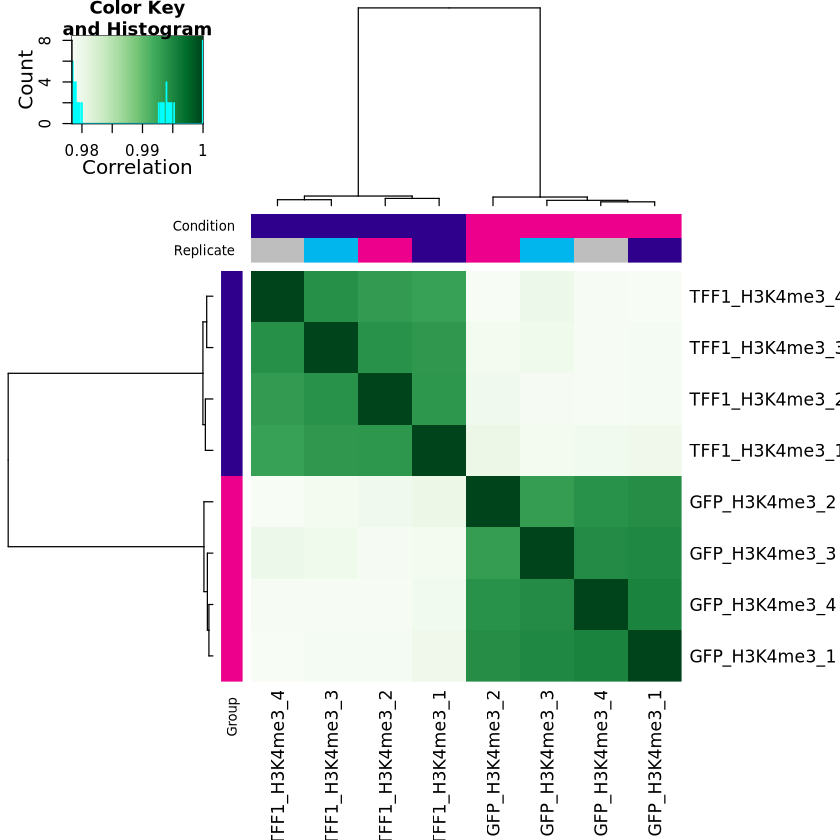

In [15]:
plot(dba_obj, contrast = 1)

In [16]:
dba_obj.DB <- dba.report(dba_obj)
dba_obj.DB

GRanges object with 11858 ranges and 6 metadata columns:
        seqnames              ranges strand |      Conc Conc_TFF1  Conc_GFP
           <Rle>           <IRanges>  <Rle> | <numeric> <numeric> <numeric>
     24     chr1   14304000-14311550      * |   9.01440   7.50113   9.73659
   8768     chr5   81017850-81024000      * |   8.60796   7.00991   9.34753
   6753     chr2 147358350-147369050      * |   9.31167   7.97295   9.99391
   9679     chr6   92937200-92946650      * |   9.13019   7.94750   9.77125
   4528    chr16   37679450-37688750      * |   8.86395   7.77468   9.47748
    ...      ...                 ...    ... .       ...       ...       ...
   5125    chr17   56503100-56517850      * |   9.25012   9.17936   9.31758
   3924    chr15   50971700-50975150      * |   6.82560   6.68888   6.95049
  10277     chr7   45133200-45149000      * |   9.16762   9.08399   9.24666
   6110     chr2   20752650-20755850      * |   6.49167   6.33126   6.63601
   4264    chr15 102001800-1020

In [17]:
sum(dba_obj.DB$Fold>0)

[1] 82

In [18]:
sum(dba_obj.DB$Fold<0)

[1] 11776

In [19]:
# Extract results — th=1 returns all peaks regardless of FDR
res_deseq2 <- dba.report(dba_obj, method=DBA_DESEQ2, th=1)
#res_edger  <- dba.report(dba_obj, method=DBA_EDGER,  th=1)

cat('--- DESeq2 ---\n')
print(head(as.data.frame(res_deseq2)))

sig_d <- res_deseq2[!is.na(res_deseq2$FDR) & res_deseq2$FDR < FDR_THRESH]

cat(sprintf('\nDESeq2: %d total | %d sig | %d TFF1 | %d GFP\n',
    length(res_deseq2), length(sig_d), sum(sig_d$Fold > 0), sum(sig_d$Fold < 0)))

#write.csv(as.data.frame(res_deseq2), file.path(OUT_DIR, paste0(TF, '_deseq2_results.csv')), row.names=FALSE)

# Save significant peak BED files (0-based start)
save_bed <- function(gr, path) {
    if (length(gr) > 0)
        write.table(data.frame(chr=seqnames(gr), start=start(gr)-1L, end=end(gr)),
                    path, sep='\t', row.names=FALSE, col.names=FALSE, quote=FALSE)
}
save_bed(sig_d[sig_d$Fold > 0], file.path(OUT_DIR, paste0(TF, '_h3k4me3_deseq2_TFF1_enriched.bed')))
save_bed(sig_d[sig_d$Fold < 0], file.path(OUT_DIR, paste0(TF, '_h3k4me3_deseq2_GFP_enriched.bed')))

--- DESeq2 ---
     seqnames     start       end width strand     Conc Conc_TFF1 Conc_GFP
24       chr1  14304000  14311550  7551      * 9.014401  7.501133 9.736590
8768     chr5  81017850  81024000  6151      * 8.607960  7.009912 9.347528
6753     chr2 147358350 147369050 10701      * 9.311667  7.972952 9.993906
9679     chr6  92937200  92946650  9451      * 9.130189  7.947497 9.771245
4528    chr16  37679450  37688750  9301      * 8.863945  7.774677 9.477477
682      chr1 187606350 187613750  7401      * 8.136444  8.822216 6.783299
          Fold       p.value           FDR
24   -2.235457 2.709735e-142 3.408305e-138
8768 -2.337617 3.948390e-133 2.483143e-129
6753 -2.020953 1.103764e-131 4.627714e-128
9679 -1.823748 3.089516e-112 9.714984e-109
4528 -1.702799  4.966778e-98  1.249443e-94
682   2.038916  1.892101e-91  3.966474e-88

DESeq2: 12578 total | 11858 sig | 82 TFF1 | 11776 GFP


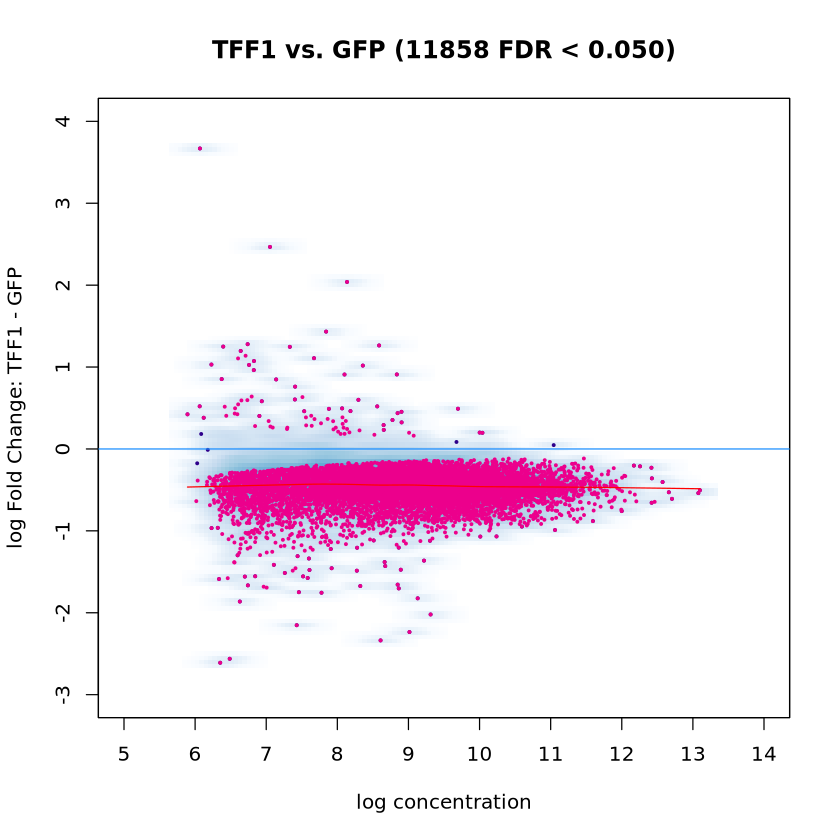

In [20]:
dba.plotMA(dba_obj, method=DBA_DESEQ2)

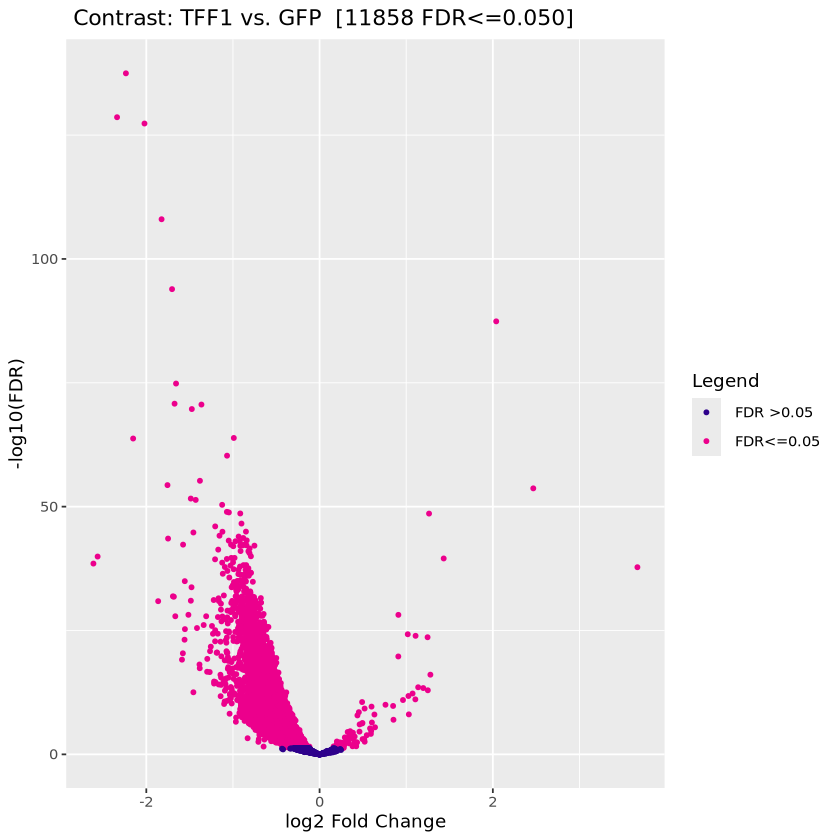

In [21]:
dba.plotVolcano(dba_obj, method=DBA_DESEQ2)

In [22]:
txdb <- makeTxDbFromGFF(GTF, format='gtf')

Import genomic features from the file as a GRanges object ... 
OK

Prepare the 'metadata' data frame ... 
OK

Make the TxDb object ... 
OK



In [23]:
# Annotate all peaks from DESeq2 and edgeR output (th=1, includes non-significant)
# ChIPseeker: TSS window defined in the settings cell (TSS_UP / TSS_DOWN)

annotate_gr <- function(gr, txdb, tss_up, tss_down) {
    anno <- annotatePeak(
        gr,
        TxDb      = txdb,
        tssRegion = c(-tss_up, tss_down),
        annoDb    = 'org.Mm.eg.db'
    )
    df <- as.data.frame(anno)
    names(df)[names(df) == 'p-value'] <- 'pvalue'
    df
}

anno_d <- annotate_gr(res_deseq2, txdb, TSS_UP, TSS_DOWN)

tag <- function(df) {
    df$significant <- !is.na(df$FDR) & df$FDR < FDR_THRESH
    df$direction   <- ifelse(!df$significant, 'NS',
                      ifelse(df$Fold > 0, 'TFF1', 'GFP'))
    df
}
anno_d <- tag(anno_d)

#write.csv(anno_d, file.path(OUT_DIR, paste0(TF, '_deseq2_annotated.csv')), row.names=FALSE)

cat(sprintf('DESeq2: %d total peaks annotated (%d sig)\n', nrow(anno_d), sum(anno_d$significant)))

cat('Annotation columns:', paste(names(anno_d), collapse=', '), '\n\n')
preview_cols <- intersect(
    c('seqnames', 'start', 'end', 'Fold', 'FDR', 'annotation', 'SYMBOL', 'distanceToTSS'),
    names(anno_d)
)
head(anno_d[, preview_cols])

>> preparing features information...		 2026-04-28 20:07:06 
>> identifying nearest features...		 2026-04-28 20:07:06 
>> calculating distance from peak to TSS...	 2026-04-28 20:07:07 
>> assigning genomic annotation...		 2026-04-28 20:07:07 
>> adding gene annotation...			 2026-04-28 20:07:11 


Warning message in annotatePeak(gr, TxDb = txdb, tssRegion = c(-tss_up, tss_down), :
“Unknown ID type, gene annotation will not be added...”


>> assigning chromosome lengths			 2026-04-28 20:07:11 
>> done...					 2026-04-28 20:07:11 
DESeq2: 12578 total peaks annotated (11858 sig)
Annotation columns: seqnames, start, end, width, strand, Conc, Conc_TFF1, Conc_GFP, Fold, p.value, FDR, annotation, geneChr, geneStart, geneEnd, geneLength, geneStrand, geneId, transcriptId, distanceToTSS, significant, direction 



,seqnames,start,end,Fold,FDR,annotation,distanceToTSS
,<fct>,<int>,<int>,<dbl>,<dbl>,<chr>,<dbl>
1,chr1,14304000,14311550,-2.235457,3.408305e-138,Promoter (<=1kb),0
2,chr5,81017850,81024000,-2.337617,2.483143e-129,Promoter (<=1kb),0
3,chr2,147358350,147369050,-2.020953,4.627714e-128,Promoter (<=1kb),0
4,chr6,92937200,92946650,-1.823748,9.714984e-109,Promoter (<=1kb),0
5,chr16,37679450,37688750,-1.702799,1.249443e-94,Distal Intergenic,-25082
6,chr1,187606350,187613750,2.038916,3.966474e-88,Promoter (<=1kb),0


>> preparing features information...		 2026-04-28 20:07:11 
>> identifying nearest features...		 2026-04-28 20:07:11 
>> calculating distance from peak to TSS...	 2026-04-28 20:07:11 
>> assigning genomic annotation...		 2026-04-28 20:07:11 
>> assigning chromosome lengths			 2026-04-28 20:07:12 
>> done...					 2026-04-28 20:07:12 
>> preparing features information...		 2026-04-28 20:07:12 
>> identifying nearest features...		 2026-04-28 20:07:12 
>> calculating distance from peak to TSS...	 2026-04-28 20:07:12 
>> assigning genomic annotation...		 2026-04-28 20:07:12 
>> assigning chromosome lengths			 2026-04-28 20:07:13 
>> done...					 2026-04-28 20:07:13 


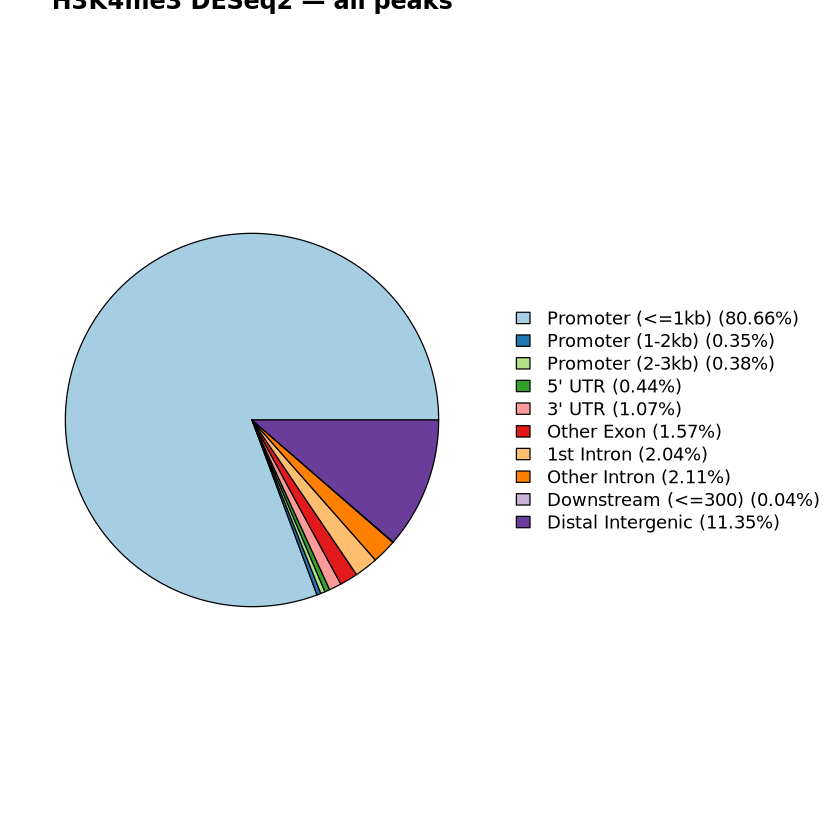

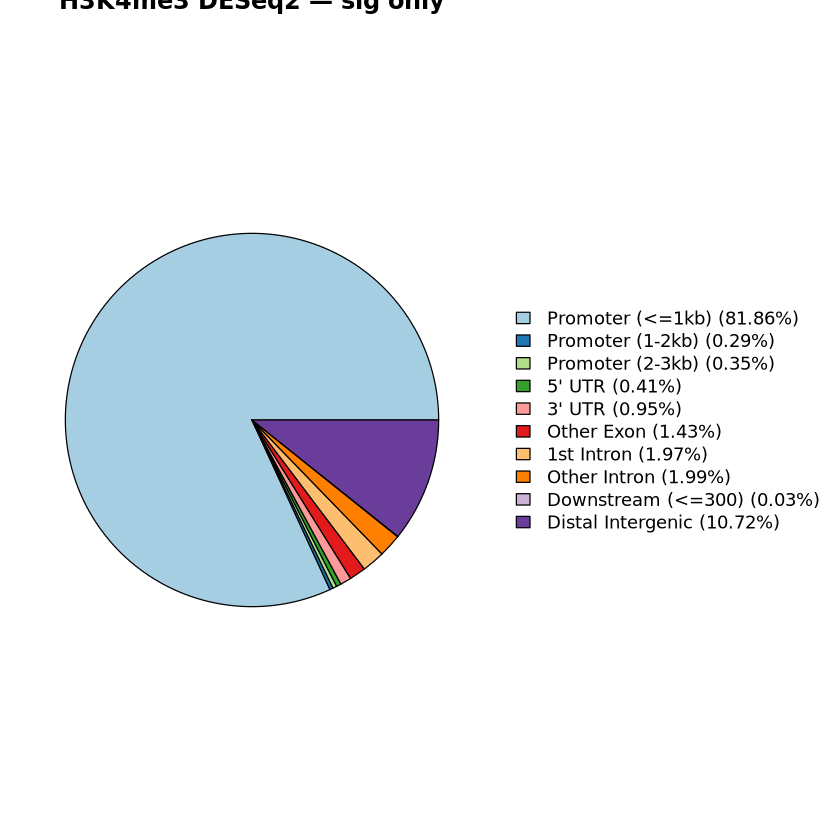

In [24]:

plot_pies <- function(gr_all, gr_sig, label, txdb, tss_up, tss_down) {
    anno_all <- annotatePeak(gr_all, TxDb=txdb, tssRegion=c(-tss_up, tss_down))
    if (length(gr_sig) > 0) {
        par(mfrow=c(1,2))
        plotAnnoPie(anno_all, main=paste(TF, label, '— all peaks'))
        anno_sig <- annotatePeak(gr_sig, TxDb=txdb, tssRegion=c(-tss_up, tss_down))
        plotAnnoPie(anno_sig, main=paste(TF, label, '— sig only'))
    } else {
        par(mfrow=c(1,1))
        plotAnnoPie(anno_all, main=paste(TF, label, '— all peaks (0 sig)'))
    }
}

plot_pies(res_deseq2, sig_d, 'DESeq2', txdb, TSS_UP, TSS_DOWN)

In [25]:
tff1_sig  <- anno_d[!is.na(anno_d$direction) & anno_d$direction == 'TFF1',  ]
gfp_sig <- anno_d[!is.na(anno_d$direction) & anno_d$direction == 'GFP', ]

write.csv(anno_d,    file.path(OUT_DIR, paste0(TF, '_deseq2_all_results.csv')),    row.names=FALSE)
write.csv(tff1_sig,  file.path(OUT_DIR, paste0(TF, '_deseq2_tff1_enriched.csv')),  row.names=FALSE)
write.csv(gfp_sig, file.path(OUT_DIR, paste0(TF, '_deseq2_gfp_enriched.csv')), row.names=FALSE)

cat(sprintf('Saved CSVs to %s/\n  All: %d | TFF1-enriched: %d | GFP-enriched: %d\n',
    OUT_DIR, nrow(anno_d), nrow(tff1_sig), nrow(gfp_sig)))


saveRDS(dba_obj, file = file.path(OUT_DIR, 'h3k4me3_dba_object.rds'))

Saved CSVs to 0_outputs/
  All: 12578 | TFF1-enriched: 82 | GFP-enriched: 11776
